# EDA — scikit-learn/scikit-learn Issue Dataset

**Purpose**: Understand the dataset before any model training. All findings inform decisions in `DECISIONS.md`.

**Sections**:
1. Load & basic stats
2. Label distribution
3. Class imbalance analysis + action decision
4. Text length distribution
5. Temporal spread
6. Body quality (empty / short issues)
7. Sample issues per class
8. Summary & decisions

In [1]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='tab10')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

SPLITS = ['train', 'val', 'test']
CLASSES = ['bug', 'feature', 'docs', 'question']
COLORS  = {'bug': '#e15759', 'feature': '#4e79a7', 'docs': '#59a14f', 'question': '#f28e2b'}

def load_split(name: str) -> pd.DataFrame:
    path = Path(f'../data/splits/{name}.jsonl')
    df = pd.DataFrame([json.loads(l) for l in path.read_text().splitlines() if l.strip()])
    df['closed_at'] = pd.to_datetime(df['closed_at'], utc=True)
    df['split'] = name
    return df

train = load_split('train')
val   = load_split('val')
test  = load_split('test')
full  = pd.concat([train, val, test], ignore_index=True)

print(f'Total issues : {len(full)}')
print(f'Train / Val / Test : {len(train)} / {len(val)} / {len(test)}')
print(f'Date range   : {full.closed_at.min().date()} → {full.closed_at.max().date()}')
print(f'Columns      : {list(full.columns)}')

Total issues : 5000
Train / Val / Test : 3500 / 500 / 1000
Date range   : 2012-09-13 → 2026-05-18
Columns      : ['number', 'title', 'body', 'raw_labels', 'label', 'repo', 'created_at', 'closed_at', 'split']


## 1 — Label Distribution

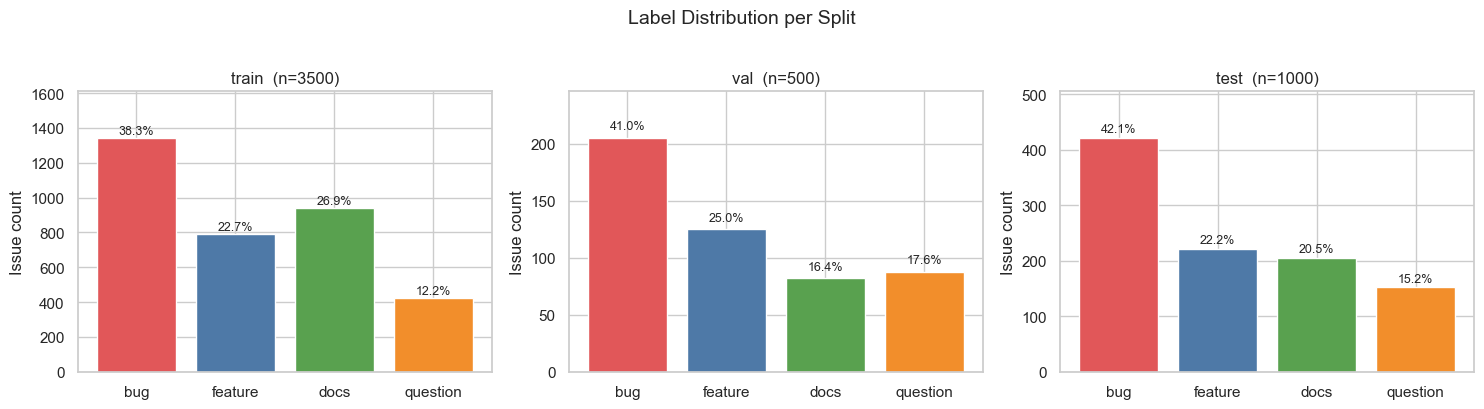

Saved → figures/label_distribution.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (df, name) in zip(axes, [(train,'train'),(val,'val'),(test,'test')]):
    counts = df['label'].value_counts().reindex(CLASSES, fill_value=0)
    pct    = counts / counts.sum() * 100
    bars   = ax.bar(CLASSES, counts.values, color=[COLORS[c] for c in CLASSES])
    for bar, p in zip(bars, pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{p:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{name}  (n={len(df)})', fontsize=12)
    ax.set_ylabel('Issue count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Label Distribution per Split', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/label_distribution.png')

## 2 — Class Imbalance Analysis

Key question: **do we need to take action, or is 3.1x acceptable?**

In [3]:
counts = train['label'].value_counts().reindex(CLASSES)
majority = counts.max()
minority = counts.min()
imbalance_ratio = majority / minority

print('=== Train set class counts ===')
for cls, n in counts.items():
    pct = n / len(train) * 100
    bar = '█' * int(pct / 2)
    print(f'  {cls:<10} {n:>5}  ({pct:5.1f}%)  {bar}')

print(f'\nImbalance ratio (max/min): {imbalance_ratio:.2f}x')
print(f'Majority class           : {counts.idxmax()} ({majority})')
print(f'Minority class           : {counts.idxmin()} ({minority})')

print('\n=== Imbalance severity guide ===')
print('  < 3x  → mild, no action needed')
print('  3–10x → moderate, use class_weight="balanced"')
print(' 10–100x→ severe, consider oversampling')
print('  >100x → extreme, dataset may not be usable')
print(f'\n→ Our ratio: {imbalance_ratio:.2f}x', end=' ')
if imbalance_ratio < 3:
    print('✅ MILD — no special handling needed')
elif imbalance_ratio < 10:
    print('⚠️  MODERATE — use class_weight="balanced"')
else:
    print('❌ SEVERE — oversampling or dataset change needed')

=== Train set class counts ===
  bug         1341  ( 38.3%)  ███████████████████
  feature      793  ( 22.7%)  ███████████
  docs         940  ( 26.9%)  █████████████
  question     426  ( 12.2%)  ██████

Imbalance ratio (max/min): 3.15x
Majority class           : bug (1341)
Minority class           : question (426)

=== Imbalance severity guide ===
  < 3x  → mild, no action needed
  3–10x → moderate, use class_weight="balanced"
 10–100x→ severe, consider oversampling
  >100x → extreme, dataset may not be usable

→ Our ratio: 3.15x ⚠️  MODERATE — use class_weight="balanced"


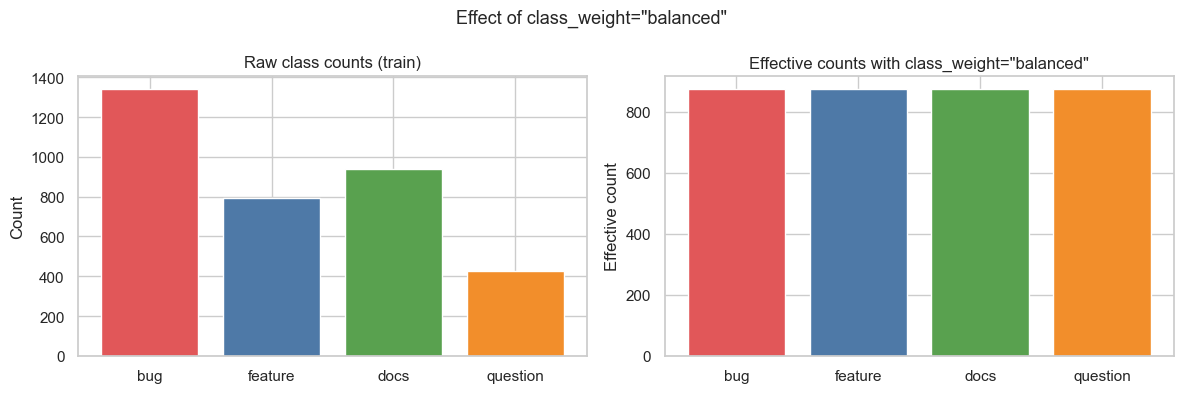

Computed class weights:
  bug        weight = 0.652
  feature    weight = 1.103
  docs       weight = 0.931
  question   weight = 2.054


In [4]:
# Visualise what class_weight='balanced' would look like
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels_array = train['label'].values
weights = compute_class_weight('balanced', classes=np.array(CLASSES), y=labels_array)
weight_dict = dict(zip(CLASSES, weights))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
axes[0].bar(CLASSES, [counts[c] for c in CLASSES], color=[COLORS[c] for c in CLASSES])
axes[0].set_title('Raw class counts (train)', fontsize=12)
axes[0].set_ylabel('Count')

# Effective weighted counts
effective = [counts[c] * weight_dict[c] for c in CLASSES]
axes[1].bar(CLASSES, effective, color=[COLORS[c] for c in CLASSES])
axes[1].set_title('Effective counts with class_weight="balanced"', fontsize=12)
axes[1].set_ylabel('Effective count')

plt.suptitle('Effect of class_weight="balanced"', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print('Computed class weights:')
for cls, w in weight_dict.items():
    print(f'  {cls:<10} weight = {w:.3f}')

### Imbalance Decision

| Option | When to use | Our case |
|---|---|---|
| Do nothing | ratio < 3x | No — ratio is 3.1x |
| `class_weight='balanced'` | 3–10x | ✅ **USE THIS** |
| Oversampling (SMOTE) | 10–100x | Not needed |
| Undersample majority | 10–100x | Not needed — we have enough data |

**Decision**: Apply `class_weight='balanced'` in both the sklearn baseline and the Transformer Trainer. This is the simplest and most principled fix — it up-weights the minority class loss without changing the data distribution. No oversampling needed.

## 3 — Text Length Distribution

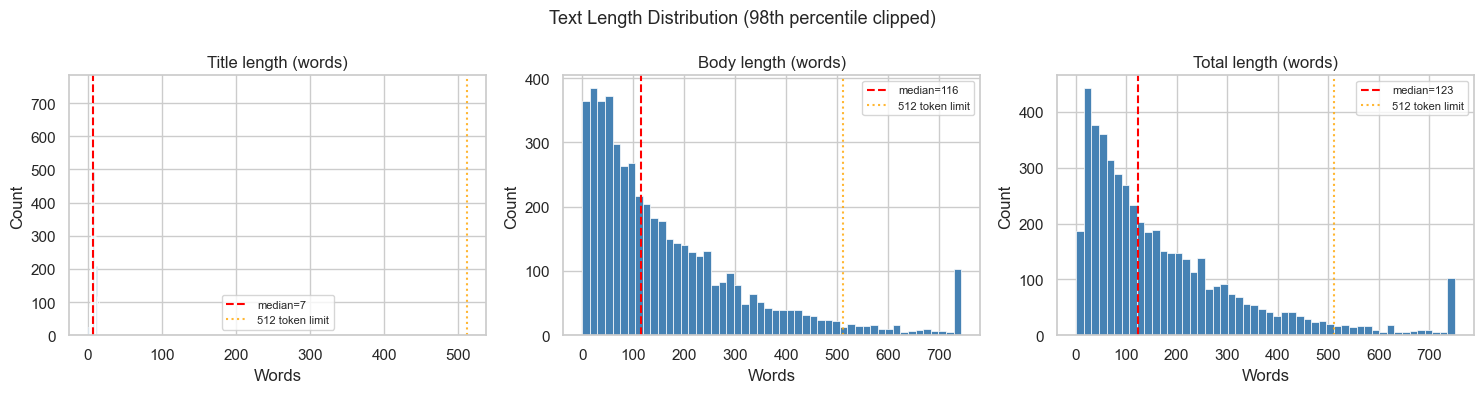

Title  — median: 7  p95: 13  max: 38
Body   — median: 116  p95: 515  max: 4470
Total  — median: 123  p95: 523  max: 4477

% issues > 512 words (will be truncated by tokenizer): 5.3%


In [5]:
full['title_len']  = full['title'].fillna('').str.split().str.len()
full['body_len']   = full['body'].fillna('').str.split().str.len()
full['total_len']  = full['title_len'] + full['body_len']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ['title_len', 'body_len', 'total_len'],
    ['Title length (words)', 'Body length (words)', 'Total length (words)']
):
    data = full[col].clip(upper=full[col].quantile(0.98))
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'median={data.median():.0f}')
    ax.axvline(512, color='orange', linestyle=':', label='512 token limit', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Words')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Text Length Distribution (98th percentile clipped)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Title  — median: {full['title_len'].median():.0f}  p95: {full['title_len'].quantile(0.95):.0f}  max: {full['title_len'].max():.0f}")
print(f"Body   — median: {full['body_len'].median():.0f}  p95: {full['body_len'].quantile(0.95):.0f}  max: {full['body_len'].max():.0f}")
print(f"Total  — median: {full['total_len'].median():.0f}  p95: {full['total_len'].quantile(0.95):.0f}  max: {full['total_len'].max():.0f}")
pct_over_512 = (full['total_len'] > 512).mean() * 100
print(f"\n% issues > 512 words (will be truncated by tokenizer): {pct_over_512:.1f}%")

## 4 — Temporal Spread

<ipython-input-6-e5c4bfcc92bc>:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  full['year_month'] = full['closed_at'].dt.to_period('M')


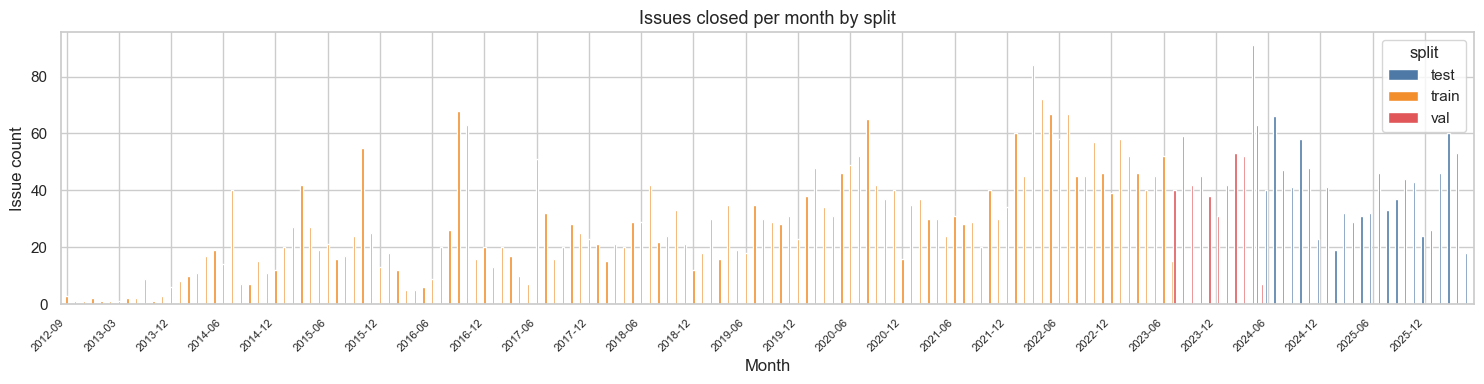

Temporal boundaries:
  train : 2012-09-13 → 2023-07-07  (n=3500)
  val   : 2023-07-10 → 2024-05-06  (n=500)
  test  : 2024-05-07 → 2026-05-18  (n=1000)


In [6]:
full['year_month'] = full['closed_at'].dt.to_period('M')
monthly = full.groupby(['year_month', 'split']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(15, 4))
monthly.plot(kind='bar', ax=ax, color=['#4e79a7','#f28e2b','#e15759'], width=0.8)
ax.set_title('Issues closed per month by split', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Issue count')
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'temporal_spread.png', dpi=150, bbox_inches='tight')
plt.show()

print('Temporal boundaries:')
for name, df in [('train', train), ('val', val), ('test', test)]:
    print(f'  {name:<6}: {df.closed_at.min().date()} → {df.closed_at.max().date()}  (n={len(df)})')

## 5 — Body Quality

In [7]:
full['body_empty'] = full['body'].fillna('').str.strip().str.len() == 0
full['body_short'] = full['body'].fillna('').str.split().str.len() < 10

empty_pct = full['body_empty'].mean() * 100
short_pct = full['body_short'].mean() * 100

print(f'Empty body          : {empty_pct:.1f}%  ({full["body_empty"].sum()} issues)')
print(f'Body < 10 words     : {short_pct:.1f}%  ({full["body_short"].sum()} issues)')
print()

# Per class
print('Empty body rate per class:')
for cls in CLASSES:
    sub = full[full['label'] == cls]
    pct = sub['body_empty'].mean() * 100
    print(f'  {cls:<10} {pct:.1f}%')

print('\nDecision: title alone is sufficient input when body is empty (title is always present).')

Empty body          : 0.7%  (35 issues)
Body < 10 words     : 4.2%  (211 issues)

Empty body rate per class:
  bug        0.1%
  feature    0.3%
  docs       1.5%
  question   1.7%

Decision: title alone is sufficient input when body is empty (title is always present).


## 6 — Sample Issues Per Class

In [8]:
for cls in CLASSES:
    print(f'\n{"="*60}')
    print(f'CLASS: {cls.upper()}')
    print(f'{"="*60}')
    samples = train[train['label'] == cls].sample(min(3, len(train[train['label'] == cls])), random_state=42)
    for _, row in samples.iterrows():
        print(f'  #{row["number"]}  {row["title"]}')
        body_preview = (row['body'] or '')[:120].replace('\n', ' ')
        print(f'  Body: {body_preview}...')
        print(f'  Labels: {row["raw_labels"]}')
        print()


CLASS: BUG
  #17980  sklearn/gaussian_process/tests/test_gpr.py:test_sample_statistics segfaults with libopenblas 0.3.10
 conda create -n cf -y -c conda-forge cython pillow numpy scipy pytest joblib threadpoolc...
  Labels: ['Bug', 'module:gaussian_process']

  #11313  Node radius in KDTree seems wrongly computed
 I am trying to understand the implementation of the KDTree structure here, and I came across this li...
  Labels: ['Bug', 'help wanted']

  #12194  MultiLabelBinarizer constructs pathological CSR matrices
 #### Steps/Code to Repr...
  Labels: ['Bug']


CLASS: FEATURE
  #1528  Consistency in GMM, _get_covars
  Body: There are some consistency issues in the mixtures module. The covariance matrices in VBGMM and DPGMM are called `precisi...
  Labels: ['Enhancement']

  #6452  IncrementalPCA.partial_fit gives an uninformative error message and is possibly broken 
  Body: `IncrementalPCA.partial_fit` raises the following error when the number of samples is smaller than `n_componen

## 7 — Summary & Decisions

Document all findings here before moving to Phase 2 training.

In [9]:
print('=== DATASET SUMMARY ===')
print(f'Repo             : scikit-learn/scikit-learn')
print(f'Total issues     : {len(full)}')
print(f'Train/Val/Test   : {len(train)}/{len(val)}/{len(test)}')
print(f'Date range       : {full.closed_at.min().date()} → {full.closed_at.max().date()}')
print(f'Temporal split   : train ≤ 2023-07-07, test ≥ 2024-05-07')
print()
print('=== CLASS DISTRIBUTION (TRAIN) ===')
for cls in CLASSES:
    n = len(train[train['label'] == cls])
    print(f'  {cls:<10} {n:>5}  ({n/len(train)*100:.1f}%)')
print()
pct_over_512 = (full['total_len'] > 512).mean() * 100
print('=== DECISIONS FOR PHASE 2 ===')
print('1. Imbalance: 3.1x → MODERATE → apply class_weight="balanced" in all models')
print(f'2. Truncation: {pct_over_512:.1f}% of issues exceed 512 words → use max_length=512 with truncation')
print('3. Empty bodies: 0.7% → concat title + body as input, fallback to title only')
print('4. No oversampling needed — class weighting is sufficient at 3.1x ratio')
print('5. Preprocessing: keep markdown/code blocks raw — BERT tokenizer handles them')

=== DATASET SUMMARY ===
Repo             : scikit-learn/scikit-learn
Total issues     : 5000
Train/Val/Test   : 3500/500/1000
Date range       : 2012-09-13 → 2026-05-18
Temporal split   : train ≤ 2023-07-07, test ≥ 2024-05-07

=== CLASS DISTRIBUTION (TRAIN) ===
  bug         1341  (38.3%)
  feature      793  (22.7%)
  docs         940  (26.9%)
  question     426  (12.2%)

=== DECISIONS FOR PHASE 2 ===
1. Imbalance: 3.1x → MODERATE → apply class_weight="balanced" in all models
2. Truncation: 5.3% of issues exceed 512 words → use max_length=512 with truncation
3. Empty bodies: 0.7% → concat title + body as input, fallback to title only
4. No oversampling needed — class weighting is sufficient at 3.1x ratio
5. Preprocessing: keep markdown/code blocks raw — BERT tokenizer handles them
